In [1]:
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
round00_epochs = 20
next_rounds_epochs = 20

list_of_init_df = []
chosen_model = []

for i in range(5):
    
    df = pd.read_csv(f'csv_logs/VAE_noise05_new_init_fold{i}.csv')

    max_val_loss = 10
    
    print("\nFold ",i)

    print(len(df[(df['epoch']==round00_epochs-1)&(df['val_loss']>max_val_loss)]),"/",len(df[df['epoch']==round00_epochs-1]), " non converging initializations")
    print( (df[(df['epoch']==round00_epochs-1)&(df['val_loss']>max_val_loss)].index-round00_epochs-1)/round00_epochs )

    #print("Minimum val. loss at epoch ",round00_epochs," for model ",np.argmin(df[df['epoch']==round00_epochs-1]['val_loss']))

    best_model = math.floor(np.argmin(df['val_loss'])/round00_epochs)
    print("Minimum val. loss for model ",best_model)
    chosen_model.append(best_model)
    #print(df.iloc[best_model*20:(best_model+1)*20])
    #print(np.min(df['val_loss']))
    
    d0 = [] 
    d1 = [] 
    d2 = [] 
    d3 = [] 
    d4 = [] 

    d = []
    last_epoch = 0

    for index, row in df.iterrows():

        if index==0:
            d.append(row)
            last_epoch = row['epoch']  
            continue

        if (row['epoch']==0) or (row['epoch']==round00_epochs) or \
           (row['epoch']==round00_epochs+next_rounds_epochs) or \
           (row['epoch']==round00_epochs+2*next_rounds_epochs) or \
           (row['epoch']==round00_epochs+3*next_rounds_epochs):
            if last_epoch < round00_epochs :
                d0.append(d.copy())
            elif last_epoch < round00_epochs+next_rounds_epochs :
                d1.append(d.copy())
            elif last_epoch < round00_epochs+2*next_rounds_epochs :
                d2.append(d.copy())
            elif last_epoch < round00_epochs+3*next_rounds_epochs :
                d3.append(d.copy())
            else :
                d4.append(d.copy()) 
            d.clear()    
        elif row['epoch'] < last_epoch :
            if last_epoch < round00_epochs :
                d0.append(d.copy())
            elif last_epoch < round00_epochs+next_rounds_epochs :
                d1.append(d.copy())
            elif last_epoch < round00_epochs+2*next_rounds_epochs :
                d2.append(d.copy())
            elif last_epoch < round00_epochs+3*next_rounds_epochs :
                d3.append(d.copy())
            else :
                d4.append(d.copy()) 
            d.clear()

        d.append(row)
        last_epoch = row['epoch']

    if last_epoch < round00_epochs :
        d0.append(d.copy())
    elif last_epoch < round00_epochs+next_rounds_epochs :
        d1.append(d.copy())
    elif last_epoch < round00_epochs+2*next_rounds_epochs :
        d2.append(d.copy())
    elif last_epoch < round00_epochs+3*next_rounds_epochs :
        d3.append(d.copy())
    else :
        d4.append(d.copy()) 
    d.clear()

    list_of_init_df.append(d0)


Fold  0
1 / 10  non converging initializations
Index([3.9], dtype='float64')
Minimum val. loss for model  0

Fold  1
1 / 10  non converging initializations
Index([2.9], dtype='float64')
Minimum val. loss for model  7

Fold  2
3 / 10  non converging initializations
Index([1.9, 6.9, 8.9], dtype='float64')
Minimum val. loss for model  4

Fold  3
1 / 10  non converging initializations
Index([4.9], dtype='float64')
Minimum val. loss for model  9

Fold  4
0 / 10  non converging initializations
Index([], dtype='float64')
Minimum val. loss for model  1


In [3]:
def ExtractEpoch(lst):
    return [item['epoch'] for item in lst]

def ExtractLoss(lst):
    return [item['loss'] for item in lst]

def ExtractValLoss(lst):
    return [item['val_loss'] for item in lst]

def ExtractKLLoss(lst):
    return [item['kl_loss'] for item in lst]

def ExtractValKLLoss(lst):
    return [item['val_kl_loss'] for item in lst]

def ExtractRecLoss(lst):
    return [item['reconstruction_loss'] for item in lst]

def ExtractValRecLoss(lst):
    return [item['val_reconstruction_loss'] for item in lst]

def ExtractLR(lst):
    return [item['lr'] for item in lst]

In [4]:
list_of_df = []

for i in range(5):
    df = pd.read_csv(f'csv_logs/VAE_noise05_new_fold{i:01d}.csv')
    list_of_df.append(df)

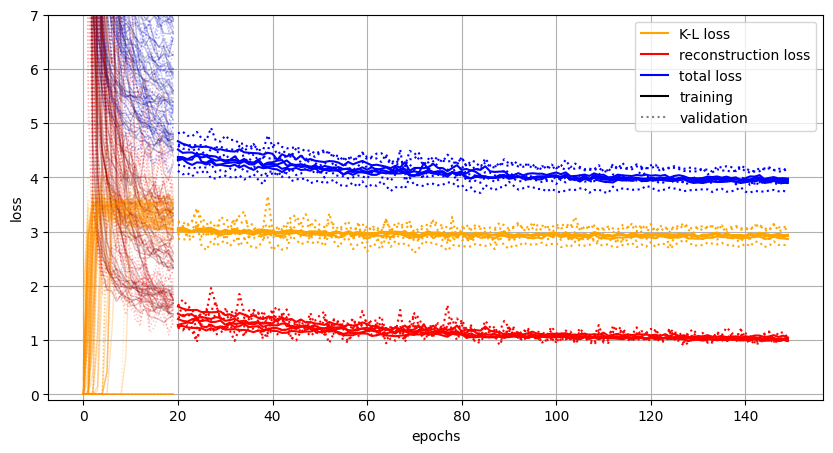

In [22]:
plt.figure(figsize=(10,5))

colors=['red','blue','green','orange','violet']

for i, d0 in enumerate(list_of_init_df) :
    for j, x in enumerate(d0) :
        plt.plot( ExtractEpoch(x), ExtractLoss(x), color='darkblue', lw=1, alpha=0.25)
        plt.plot( ExtractEpoch(x), ExtractValLoss(x), color='blue', alpha=0.25, lw=1, linestyle=':')
        plt.plot( ExtractEpoch(x), ExtractKLLoss(x), color='darkorange', lw=1, alpha=0.25)
        plt.plot( ExtractEpoch(x), ExtractValKLLoss(x), color='orange', alpha=0.25, lw=1, linestyle=':')
        plt.plot( ExtractEpoch(x), ExtractRecLoss(x), color='darkred', lw=1, alpha=0.25)
        plt.plot( ExtractEpoch(x), ExtractValRecLoss(x), color='red', alpha=0.25, lw=1, linestyle=':')
        #if i==best_model:
        #    plt.plot( ExtractEpoch(x), ExtractLoss(x), label='train', color='black')
        #    plt.plot( ExtractEpoch(x), ExtractValLoss(x), label='validation', color='black', linestyle='-.')    


for i, df in enumerate(list_of_df) :
    plt.plot( df['epoch'], df['loss'], color='blue')
    plt.plot( df['epoch'], df['val_loss'], color='blue', linestyle=':')
    plt.plot( df['epoch'], df['kl_loss'], color='orange')
    plt.plot( df['epoch'], df['val_kl_loss'], color='orange', linestyle=':')
    plt.plot( df['epoch'], df['reconstruction_loss'], color='red')
    plt.plot( df['epoch'], df['val_reconstruction_loss'], color='red', linestyle=':')


plt.plot([0,0],[0,0], color='orange', label='K-L loss')
plt.plot([0,0],[0,0], color='red', label='reconstruction loss')
plt.plot([0,0],[0,0], color='blue', label='total loss')

plt.plot([0,0],[0,0], color='black', label='training')
plt.plot([0,0],[0,0], color='gray', linestyle=':', label='validation')


plt.ylabel('loss')
plt.xlabel('epochs')

plt.legend()
#plt.yscale('log')

#plt.xlim(0,21)
#plt.xlim(0,100)

plt.ylim(-1,44)
plt.ylim(-0.1,7)
#plt.ylim(3.6,5.)
#plt.ylim(2.5,3.5)
#plt.ylim(0.8,1.6)

plt.grid()
#plt.savefig('./attemptXX.png')
plt.show()

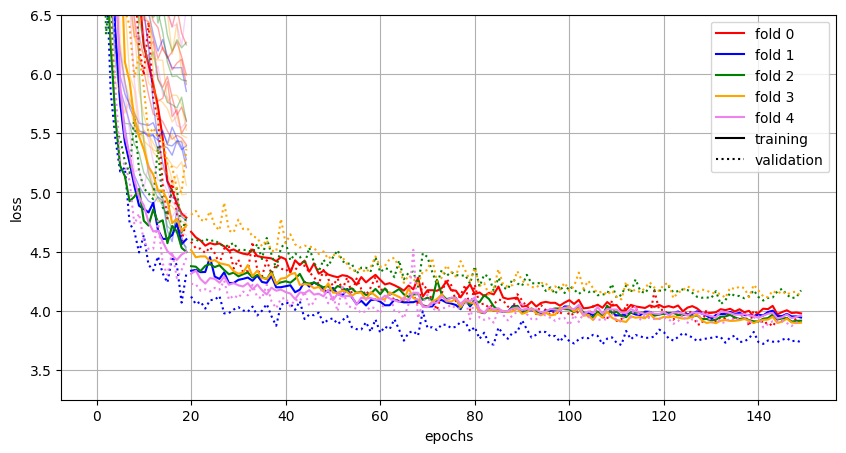

In [6]:
plt.figure(figsize=(10,5))

colors=['red','blue','green','orange','violet']

for i, d0 in enumerate(list_of_init_df) :
    for j, x in enumerate(d0) :
        plt.plot( ExtractEpoch(x), ExtractLoss(x), color=colors[i], lw=1, alpha=0.35)
        #plt.plot( ExtractEpoch(x), ExtractValLoss(x), color=colors[i], alpha=0.35, lw=1, linestyle=':')
        if j==chosen_model[i]:
            plt.plot( ExtractEpoch(x), ExtractLoss(x), color=colors[i])
            plt.plot( ExtractEpoch(x), ExtractValLoss(x), color=colors[i], linestyle=':')    


for i, df in enumerate(list_of_df) :
    plt.plot( df['epoch'], df['loss'], color=colors[i], label=f"fold {i}")
    plt.plot( df['epoch'], df['val_loss'], color=colors[i], linestyle=':')
    #plt.plot( df['epoch'], df['kl_loss'], label='train', color=colors[i])
    #plt.plot( df['epoch'], df['val_kl_loss'], label='validation', color=colors[i], linestyle=':', alpha=0.5)
    #plt.plot( df['epoch'], df['reconstruction_loss'], label='train', color=colors[i])
    #plt.plot( df['epoch'], df['val_reconstruction_loss'], label='validation', color=colors[i], linestyle=':', alpha=0.5)

plt.ylabel('loss')
plt.xlabel('epochs')

#plt.yscale('log')

#plt.xlim(0,21)
#plt.xlim(0,100)

plt.ylim(0,45)
plt.ylim(3.25,6.5)
#plt.ylim(0.5,5.5)
#plt.ylim(2.5,3.5)
#plt.ylim(0.8,1.6)

plt.plot([0,0],[0,0], color='black', label='training')
plt.plot([0,0],[0,0], color='black', linestyle=':', label='validation')

plt.legend()

plt.grid()
#plt.savefig('./attemptXX.png')
plt.show()

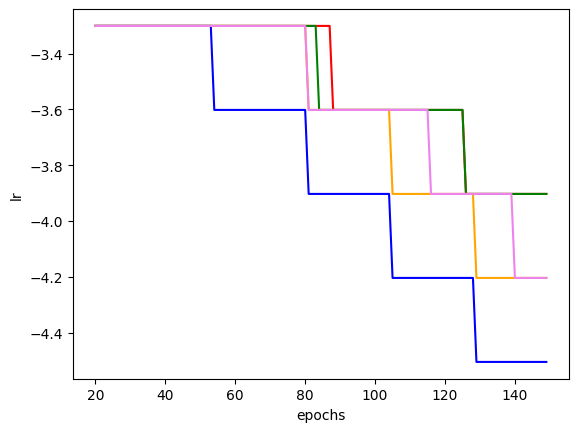

In [7]:
for i, df in enumerate(list_of_df) :
    plt.plot( df['epoch'], np.log10(df['lr']), label='lr', color=colors[i])

plt.ylabel('lr')
plt.xlabel('epochs')

#plt.yscale('log')

#plt.ylim(0,2)
#plt.ylim(0.1,0.5)
#plt.ylim(0.125,0.225)

#plt.ylim(0.15,0.22)
#plt.xlim(35,50)
plt.show()

In [8]:
peak_noise05 = [0.014125375446227547,
                0.014125375446227547,
                0.01148153621496883,
                0.03311311214825911,
                0.012302687708123818
               ]